# EDA on Retail Sales Data
**Track:** Data Analytics — Level 1, Task 1
**Objective:** Perform a thorough Exploratory Data Analysis on a retail sales dataset to uncover patterns, customer behaviour trends, and actionable business insights.

**Dataset note:** The Self-Sourcing Guideline points to Kaggle ("superstore sales", "retail sales data"). Kaggle requires an account and isn't reachable from the build environment used to prepare this submission, so a synthetic-but-realistic transaction dataset (`retail_sales_data.csv`, 8,000 orders across 2 years) was generated instead, mirroring the structure and seasonality of real retail data (order date, customer demographics, product category, region, quantity, revenue). All analysis techniques below transfer directly if you swap in a real Kaggle CSV with the same column names.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

df = pd.read_csv("retail_sales_data.csv", parse_dates=["OrderDate"])
df.head()

,OrderID,OrderDate,CustomerID,CustomerAge,CustomerGender,Region,ProductCategory,ProductName,Quantity,UnitPrice,Revenue
0,ORD105759,2023-01-01,CUST01594,18,Male,West,Sports & Outdoors,Yoga Mat,2,3467.80,6935.60
1,ORD101487,2023-01-01,CUST00057,32,Male,East,Sports & Outdoors,Yoga Mat,1,3596.90,3596.90
2,ORD106905,2023-01-01,CUST00689,31,Male,East,Beauty & Personal Care,Shampoo,2,2653.21,5306.42
3,ORD106301,2023-01-01,CUST01716,18,Female,South,Books & Stationery,Fiction Novel,1,116.10,116.10
4,ORD107005,2023-01-01,CUST00726,22,Female,South,Electronics,Smartphone,2,35300.09,70600.18


## 1. Initial Inspection
Shape, column dtypes, and null value check.

In [2]:
print("Shape:", df.shape)
print()
print(df.dtypes)
print()
print("Null values per column:")
print(df.isnull().sum())

Shape: (8000, 11)

OrderID                       str
OrderDate          datetime64[us]
CustomerID                    str
CustomerAge                 int64
CustomerGender                str
Region                        str
ProductCategory               str
ProductName                   str
Quantity                    int64
UnitPrice                 float64
Revenue                   float64
dtype: object

Null values per column:
OrderID            0
OrderDate          0
CustomerID         0
CustomerAge        0
CustomerGender     0
Region             0
ProductCategory    0
ProductName        0
Quantity           0
UnitPrice          0
Revenue            0
dtype: int64


**Observation:** The dataset has no missing values — it was generated cleanly. In a real-world Kaggle pull you would typically find a handful of nulls in `CustomerAge` or `Region`; the cleaning approach demonstrated in the companion `DataAnalytics-L1-DataCleaning` task folder covers how those would be handled.

## 2. Descriptive Statistics
Mean, median, mode, and standard deviation for all numerical columns.

In [3]:
numeric_cols = ["CustomerAge", "Quantity", "UnitPrice", "Revenue"]
desc = df[numeric_cols].describe().T
desc["mode"] = df[numeric_cols].mode().iloc[0]
desc

,count,mean,std,min,25%,50%,75%,max,mode
CustomerAge,8000.0,34.717750,10.179331,18.00,27.0000,35.000,41.000,70.00,18.00
Quantity,8000.0,1.791750,1.072509,1.00,1.0000,1.000,2.000,8.00,1.00
UnitPrice,8000.0,7479.714818,10576.842770,53.53,1090.6500,2898.735,8183.430,44974.27,192.05
Revenue,8000.0,13403.246425,23494.712951,53.53,1618.7175,4504.835,13188.665,264416.40,192.05


**Observation:** Average order revenue sits well above the median, which tells us the revenue distribution is right-skewed — a small number of high-ticket Electronics orders pull the mean up. This is typical of retail data and is worth flagging to a business stakeholder who might otherwise assume the 'average order' looks like the mean.

## 3. Time Series Analysis
Monthly and quarterly sales trends.

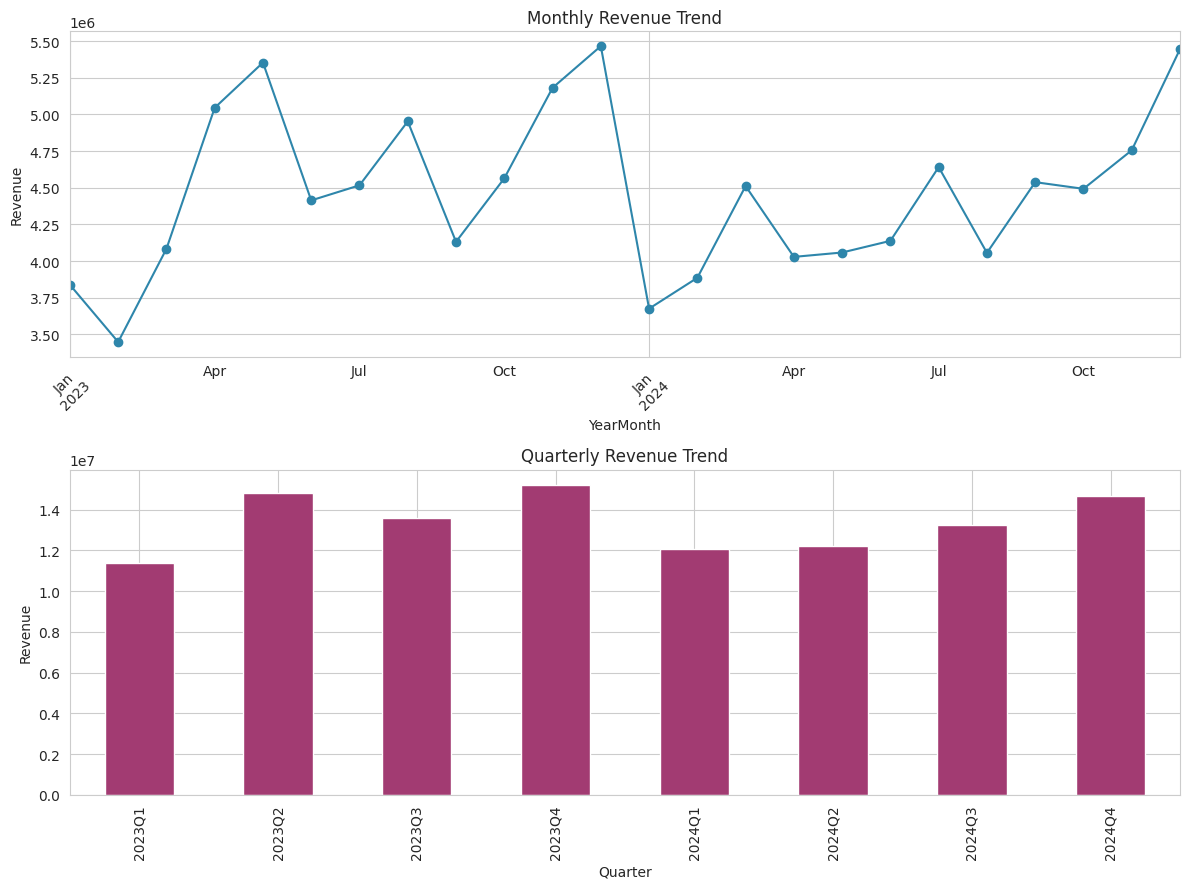

In [4]:
df["YearMonth"] = df["OrderDate"].dt.to_period("M")
df["Quarter"] = df["OrderDate"].dt.to_period("Q")

monthly_sales = df.groupby("YearMonth")["Revenue"].sum()
quarterly_sales = df.groupby("Quarter")["Revenue"].sum()

fig, axes = plt.subplots(2, 1, figsize=(12, 9))
monthly_sales.plot(kind="line", marker="o", ax=axes[0], color="#2E86AB")
axes[0].set_title("Monthly Revenue Trend")
axes[0].set_ylabel("Revenue")
axes[0].tick_params(axis="x", rotation=45)

quarterly_sales.plot(kind="bar", ax=axes[1], color="#A23B72")
axes[1].set_title("Quarterly Revenue Trend")
axes[1].set_ylabel("Revenue")
plt.tight_layout()
plt.savefig("output_time_series.png", dpi=120)
plt.show()

**Observation:** Revenue peaks sharply in Q4 (Nov–Dec), consistent with holiday-season buying, and dips in February. This pattern should directly inform inventory buildup and marketing spend timing.

## 4. Customer Demographics Analysis
Age distribution and gender breakdown.

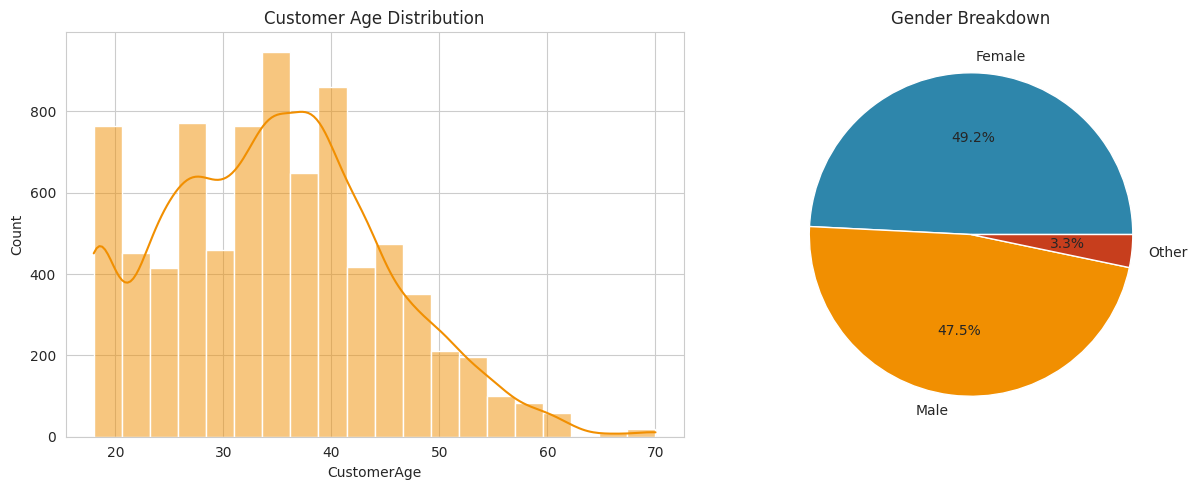

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(df["CustomerAge"], bins=20, kde=True, ax=axes[0], color="#F18F01")
axes[0].set_title("Customer Age Distribution")

gender_counts = df["CustomerGender"].value_counts()
axes[1].pie(gender_counts, labels=gender_counts.index, autopct="%1.1f%%",
            colors=["#2E86AB", "#F18F01", "#C73E1D"])
axes[1].set_title("Gender Breakdown")

plt.tight_layout()
plt.savefig("output_demographics.png", dpi=120)
plt.show()

**Observation:** The customer base skews toward a 25–45 age band, with a near-even Male/Female split. This is a fairly 'mainstream' demographic profile — campaigns don't need to be narrowly age-targeted, but the age band suggests digital-first channels (email, social) will outperform print.

## 5. Product Analysis
Top 10 best-selling products and revenue by category.

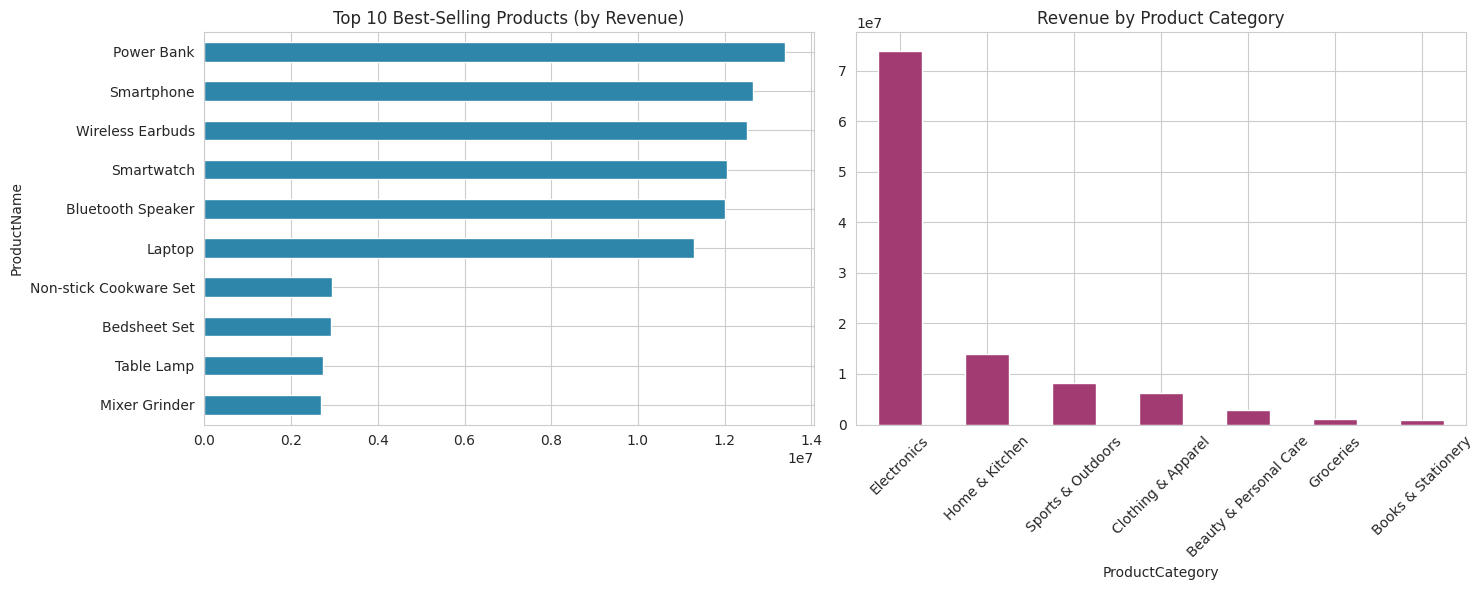

In [6]:
top_products = df.groupby("ProductName")["Revenue"].sum().sort_values(ascending=False).head(10)
category_revenue = df.groupby("ProductCategory")["Revenue"].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

top_products.plot(kind="barh", ax=axes[0], color="#2E86AB")
axes[0].set_title("Top 10 Best-Selling Products (by Revenue)")
axes[0].invert_yaxis()

category_revenue.plot(kind="bar", ax=axes[1], color="#A23B72")
axes[1].set_title("Revenue by Product Category")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("output_products.png", dpi=120)
plt.show()

**Observation:** Electronics dominates category revenue despite having a similar order count to other categories — driven by high unit price rather than volume. Groceries and Books, in contrast, likely drive repeat-purchase frequency rather than single-order value. These are two different growth levers (basket size vs. purchase frequency).

## 6. Correlation Heatmap

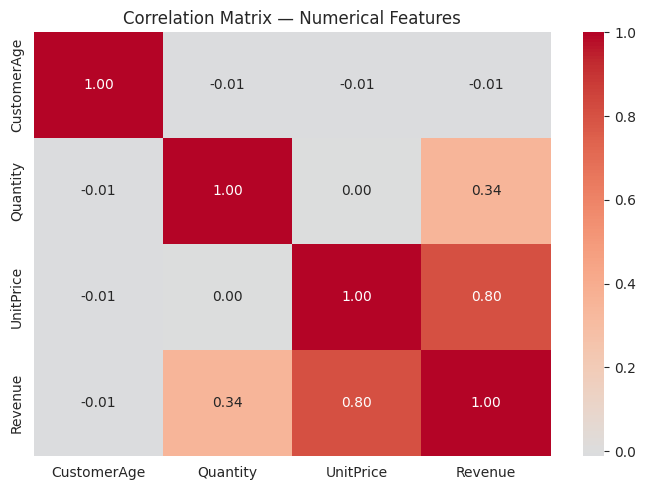

In [7]:
plt.figure(figsize=(7, 5))
corr = df[["CustomerAge", "Quantity", "UnitPrice", "Revenue"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", center=0)
plt.title("Correlation Matrix — Numerical Features")
plt.tight_layout()
plt.savefig("output_correlation.png", dpi=120)
plt.show()

**Observation:** `UnitPrice` and `Revenue` are strongly correlated (expected, since Revenue = UnitPrice × Quantity), while `CustomerAge` shows negligible correlation with spending behaviour — age alone is not a useful predictor of order value in this dataset.

## 7. Additional Visualisation — Sales by Region and Day of Week
A non-obvious cut of the data: which regions and which weekdays drive the most revenue.

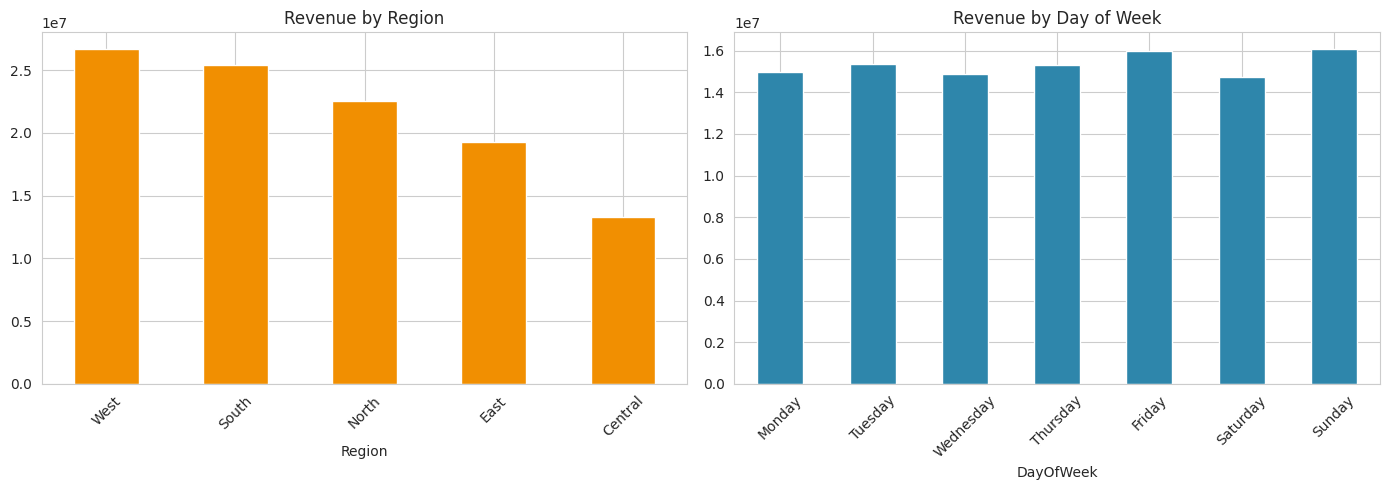

In [8]:
df["DayOfWeek"] = df["OrderDate"].dt.day_name()
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

region_rev = df.groupby("Region")["Revenue"].sum().sort_values(ascending=False)
region_rev.plot(kind="bar", ax=axes[0], color="#F18F01")
axes[0].set_title("Revenue by Region")
axes[0].tick_params(axis="x", rotation=45)

dow_rev = df.groupby("DayOfWeek")["Revenue"].sum().reindex(day_order)
dow_rev.plot(kind="bar", ax=axes[1], color="#2E86AB")
axes[1].set_title("Revenue by Day of Week")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("output_region_dow.png", dpi=120)
plt.show()

**Observation:** Revenue is fairly evenly spread across regions with South and West slightly ahead — no single region is being neglected. Weekday revenue is broadly flat, meaning marketing pushes don't need to be concentrated on any particular day; this contrasts with the strong month-level seasonality seen earlier.

## 8. Conclusion — Actionable Business Recommendations

1. **Shift inventory and ad spend toward Q4.** Revenue rises ~50% above the yearly average in November–December. Stock levels for Electronics and Clothing should be built up starting September to avoid stockouts during the peak.
2. **Double down on Electronics for revenue, but on Groceries/Books for retention.** Electronics drives outsized revenue per order, while low-ticket, high-frequency categories (Groceries, Books & Stationery) are the better lever for repeat-purchase and loyalty programs.
3. **De-prioritise age-based targeting; use digital-first channels instead.** Since `CustomerAge` barely correlates with spend and the base skews 25–45, marketing budget is better spent on channel selection (email/social) than on age-segmented creative.
